# 5a - Valutazione finale dei modelli

In questo notebook viene effettuata la valutazione finale dei sei
classificatori sviluppati durante il progetto.

Per la prima volta viene utilizzato il Test Set, mantenuto separato
durante tutte le precedenti fasi di addestramento e ottimizzazione.

I modelli valutati sono:

1. Regressione Logistica;
2. Support Vector Machine;
3. Decision Tree;
4. K-Nearest Neighbors;
5. Random Forest;
6. Gaussian Naive Bayes.

Per ciascun classificatore vengono calcolate:

- Accuracy;
- Precision;
- Recall;
- F1-Score;
- Confusion Matrix.

Il Test Set viene utilizzato esclusivamente per la valutazione finale
e non per ulteriori operazioni di tuning degli iperparametri.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Keep Out\File\Magistrale\predictLoL


## 1. Caricamento del Test Set

Il Test Set standardizzato, generato durante la fase di Data Preparation,
viene utilizzato esclusivamente in questa fase per valutare la capacità
di generalizzazione dei modelli su dati non utilizzati durante
l'addestramento e l'ottimizzazione degli iperparametri.

In [3]:
X_TEST_SCALED_PATH = PROJECT_ROOT / "data" / "X_test_scaled.csv"
X_TEST_PATH = PROJECT_ROOT / "data" / "X_test.csv"
Y_TEST_PATH = PROJECT_ROOT / "data" / "y_test.csv"

assert X_TEST_SCALED_PATH.exists(), f"File non trovato: {X_TEST_SCALED_PATH}"
assert X_TEST_PATH.exists(), f"File non trovato: {X_TEST_PATH}"
assert Y_TEST_PATH.exists(), f"File non trovato: {Y_TEST_PATH}"

X_test_scaled = pd.read_csv(X_TEST_SCALED_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH)["blueWins"]

print(f"X_test standardizzato: {X_test_scaled.shape}")
print(f"X_test non standardizzato: {X_test.shape}")
print(f"y_test: {y_test.shape}")

assert list(X_test_scaled.columns) == list(X_test.columns)

print("I due Test Set contengono le stesse feature.")

X_test standardizzato: (1976, 27)
X_test non standardizzato: (1976, 27)
y_test: (1976,)
I due Test Set contengono le stesse feature.


In [4]:
model_inputs = {
    "Logistic Regression": X_test_scaled,
    "SVM": X_test_scaled,
    "Decision Tree": X_test,
    "KNN": X_test_scaled,
    "Random Forest": X_test_scaled,
    "Gaussian Naive Bayes": X_test_scaled,
}

In [5]:
print(f"Valori mancanti in X_test: {X_test.isna().sum().sum()}")
print(f"Valori mancanti in y_test: {y_test.isna().sum()}")

print("\nDistribuzione della variabile target:")
print(y_test.value_counts())

Valori mancanti in X_test: 0
Valori mancanti in y_test: 0

Distribuzione della variabile target:
blueWins
0    990
1    986
Name: count, dtype: int64


### Rappresentazione dei dati utilizzata

Per garantire coerenza tra fase di addestramento e fase di valutazione,
ciascun modello viene valutato utilizzando la stessa rappresentazione
dei dati impiegata durante il training.

Logistic Regression, SVM, KNN, Random Forest e Gaussian Naive Bayes
utilizzano il Test Set standardizzato.

Il Decision Tree utilizza invece il Test Set non standardizzato,
poiché è stato addestrato sui dati nelle unità originali. Gli alberi
decisionali non richiedono infatti la standardizzazione delle feature.

## 2. Caricamento dei modelli ottimizzati

Vengono caricati tramite `joblib` i sei classificatori precedentemente
ottimizzati esclusivamente sul Training Set.

In [6]:
MODELS_DIR = PROJECT_ROOT / "models"

model_paths = {
    "Logistic Regression": MODELS_DIR / "logistic_regression.pkl",
    "SVM": MODELS_DIR / "svm.pkl",
    "Decision Tree": MODELS_DIR / "decision_tree.pkl",
    "KNN": MODELS_DIR / "knn_best.pkl",
    "Random Forest": MODELS_DIR / "random_forest_best.pkl",
    "Gaussian Naive Bayes": MODELS_DIR / "naive_bayes_best.pkl",
}

for model_name, model_path in model_paths.items():
    assert model_path.exists(), f"Modello non trovato: {model_path}"

print("Tutti i modelli sono presenti.")

Tutti i modelli sono presenti.


In [7]:
models = {
    model_name: joblib.load(model_path)
    for model_name, model_path in model_paths.items()
}

print("Modelli caricati:")
for model_name in models:
    print(f"- {model_name}")

Modelli caricati:
- Logistic Regression
- SVM
- Decision Tree
- KNN
- Random Forest
- Gaussian Naive Bayes


In [8]:
print(f"Numero di feature nel Test Set: {X_test.shape[1]}\n")

for model_name, model in models.items():
    if hasattr(model, "n_features_in_"):
        print(
            f"{model_name}: "
            f"{model.n_features_in_} feature attese"
        )

Numero di feature nel Test Set: 27

Logistic Regression: 27 feature attese
SVM: 27 feature attese
Decision Tree: 27 feature attese
KNN: 27 feature attese
Random Forest: 27 feature attese
Gaussian Naive Bayes: 27 feature attese


In [9]:
for model_name, model in models.items():
    X_input = model_inputs[model_name]

    if hasattr(model, "n_features_in_"):
        assert model.n_features_in_ == X_input.shape[1], (
            f"{model_name} è stato addestrato con "
            f"{model.n_features_in_} feature, "
            f"ma il Test Set ne contiene {X_input.shape[1]}."
        )

print("Tutti i modelli sono compatibili con i rispettivi Test Set.")

Tutti i modelli sono compatibili con i rispettivi Test Set.


## 3. Predizioni sul Test Set

Ogni modello viene applicato alle medesime osservazioni del Test Set, utilizzando la stessa rappresentazione dei dati adottata durante il relativo addestramento, in modo da ottenere una valutazione quantitativa direttamente confrontabile.

In [10]:
predictions = {}

for model_name, model in models.items():
    predictions[model_name] = model.predict(
        model_inputs[model_name]
    )

print("Predizioni generate per tutti i modelli.")

Predizioni generate per tutti i modelli.


In [11]:
results = []

for model_name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Modello": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
    })

In [12]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

results_df

,Modello,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.724696,0.725051,0.722110,0.723577
1,Logistic Regression,0.721154,0.718154,0.726166,0.722138
2,SVM,0.716599,0.715587,0.717039,0.716312
3,Decision Tree,0.720648,0.734341,0.689655,0.711297
4,KNN,0.707490,0.705645,0.709939,0.707786
5,Gaussian Naive Bayes,0.711538,0.715768,0.699797,0.707692


### Interpretazione delle metriche

Le metriche utilizzate permettono di valutare aspetti differenti
delle prestazioni dei classificatori.

- **Accuracy**: proporzione complessiva di predizioni corrette.
- **Precision**: tra le partite previste come vittoria del Blue Team,
  indica la proporzione effettivamente vinta dal Blue Team.
- **Recall**: tra tutte le partite effettivamente vinte dal Blue Team,
  indica la proporzione correttamente identificata dal modello.
- **F1-Score**: media armonica tra Precision e Recall e rappresenta
  una misura sintetica del loro bilanciamento.

Nel problema considerato, `blueWins = 1` rappresenta la classe positiva.

## 4. Confusion Matrix

Le Confusion Matrix permettono di analizzare nel dettaglio la tipologia
degli errori commessi da ciascun classificatore.

Considerando `blueWins = 1` come classe positiva:

- **True Negative (TN)**: viene prevista correttamente la sconfitta del Blue Team;
- **False Positive (FP)**: viene prevista una vittoria del Blue Team che in realtà perde;
- **False Negative (FN)**: viene prevista una sconfitta del Blue Team che in realtà vince;
- **True Positive (TP)**: viene prevista correttamente la vittoria del Blue Team.

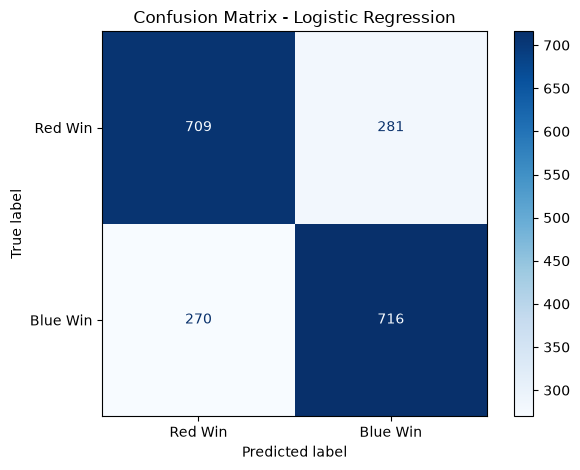

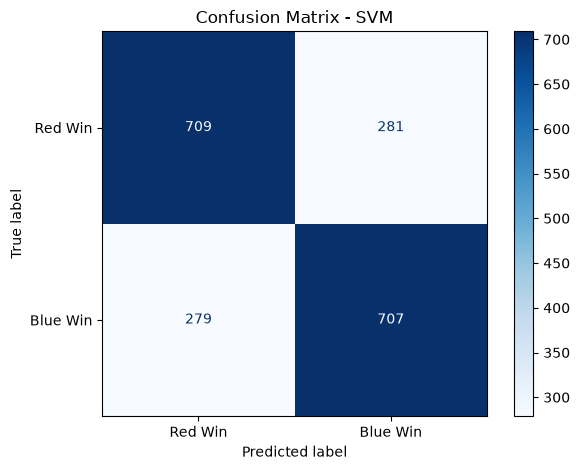

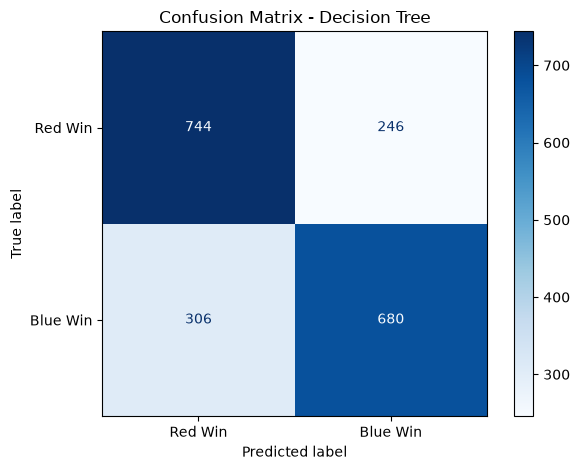

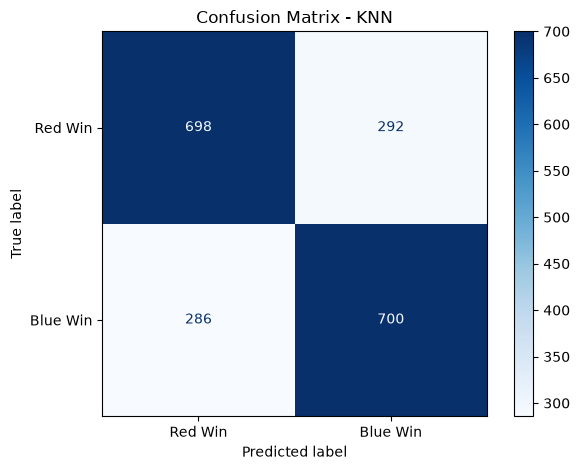

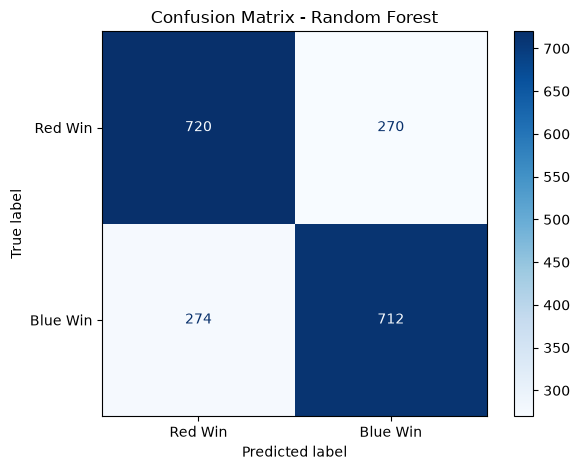

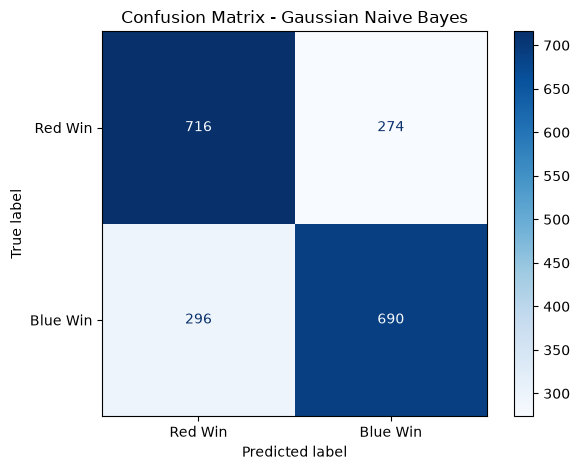

In [13]:
for model_name, y_pred in predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Red Win", "Blue Win"],
        cmap="Blues",
        values_format="d",
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

### Interpretazione di Falsi Positivi e Falsi Negativi

Nel contesto del problema, la classe positiva corrisponde a
`blueWins = 1`, cioè alla vittoria del Blue Team.

Un **Falso Positivo (FP)** si verifica quando il modello prevede
la vittoria del Blue Team, ma la partita viene in realtà vinta
dal Red Team.

Un **Falso Negativo (FN)** si verifica invece quando il modello
prevede la sconfitta del Blue Team, mentre il Blue Team risulta
effettivamente vincitore.

Un numero elevato di Falsi Positivi riduce principalmente la Precision,
mentre un numero elevato di Falsi Negativi riduce principalmente il Recall.

L'F1-Score combina Precision e Recall e consente quindi di valutare
il compromesso tra queste due tipologie di errore.

In [14]:
confusion_results = []

for model_name, y_pred in predictions.items():
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    confusion_results.append({
        "Modello": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

confusion_df = pd.DataFrame(confusion_results)

confusion_df

,Modello,TN,FP,FN,TP
0,Logistic Regression,709,281,270,716
1,SVM,709,281,279,707
2,Decision Tree,744,246,306,680
3,KNN,698,292,286,700
4,Random Forest,720,270,274,712
5,Gaussian Naive Bayes,716,274,296,690


### Analisi dei Falsi Positivi e dei Falsi Negativi

L'analisi delle Confusion Matrix evidenzia differenze nel tipo di errore commesso dai diversi classificatori.

La **Random Forest**, che presenta il miglior F1-Score complessivo, commette 270 Falsi Positivi e 274 Falsi Negativi. Le due tipologie di errore risultano quindi molto bilanciate. Questo comportamento è coerente con valori molto simili di Precision (`0.7251`) e Recall (`0.7221`) e suggerisce che il modello non mostra una particolare tendenza a favorire una delle due classi.

La **Regressione Logistica** presenta 281 Falsi Positivi e 270 Falsi Negativi. Rispetto alla Random Forest, identifica leggermente meglio le vittorie effettive del Blue Team, ottenendo infatti il Recall più elevato tra i modelli analizzati (`0.7262`). Al tempo stesso produce un numero leggermente maggiore di Falsi Positivi, che determina una Precision inferiore (`0.7182`).

La **SVM** produce 281 Falsi Positivi e 279 Falsi Negativi, mostrando un comportamento particolarmente equilibrato tra i due tipi di errore. Questo si riflette anche nella quasi uguaglianza tra Precision (`0.7156`) e Recall (`0.7170`).

Il **Decision Tree** presenta invece una distribuzione degli errori più asimmetrica: 246 Falsi Positivi e 306 Falsi Negativi. Il modello risulta quindi più prudente nel prevedere una vittoria del Blue Team. Quando effettua tale previsione tende a essere relativamente affidabile, come evidenziato dalla Precision più alta tra tutti i classificatori (`0.7343`), ma non riesce a riconoscere una parte maggiore delle vittorie effettive del Blue Team, determinando un Recall più basso (`0.6897`).

Il **KNN** registra 292 Falsi Positivi e 286 Falsi Negativi. Gli errori sono abbastanza bilanciati, ma il loro numero complessivo è maggiore rispetto ai modelli con le prestazioni migliori. Ciò si riflette in un F1-Score più basso (`0.7078`).

Infine, il **Gaussian Naive Bayes** presenta 274 Falsi Positivi e 296 Falsi Negativi. Il numero maggiore di Falsi Negativi indica una maggiore difficoltà nell'identificare tutte le vittorie effettive del Blue Team, coerentemente con il Recall relativamente basso (`0.6998`).

Nel complesso, la Random Forest offre il miglior equilibrio tra Falsi Positivi e Falsi Negativi, mentre il Decision Tree privilegia una maggiore Precision a discapito del Recall.

## 5. Confronto finale

La valutazione sul Test Set mostra che i sei classificatori raggiungono prestazioni complessivamente simili, ma con differenze nel bilanciamento tra Precision e Recall.

La **Random Forest** ottiene il miglior risultato complessivo, con un'Accuracy pari a `0.7247` e il più alto F1-Score (`0.7236`). Anche Precision (`0.7251`) e Recall (`0.7221`) risultano ben bilanciati, rendendo questo modello il classificatore con la migliore capacità complessiva di generalizzazione sul Test Set.

La **Regressione Logistica** presenta prestazioni molto vicine alla Random Forest, con un F1-Score di `0.7221`. In particolare, ottiene il Recall più elevato (`0.7262`), risultando il modello che riconosce la percentuale maggiore delle effettive vittorie del Blue Team.

La **SVM** raggiunge un F1-Score di `0.7163` e mostra un buon equilibrio tra Precision e Recall. Il **Decision Tree**, pur ottenendo un'Accuracy simile (`0.7206`), presenta un comportamento differente: raggiunge la Precision più elevata (`0.7343`) ma un Recall inferiore (`0.6897`), indicando una maggiore selettività nel prevedere la vittoria del Blue Team.

KNN e Gaussian Naive Bayes ottengono risultati leggermente inferiori, con F1-Score rispettivamente pari a `0.7078` e `0.7077`.

Considerando congiuntamente Accuracy, Precision, Recall e soprattutto F1-Score, la **Random Forest risulta quindi il modello migliore tra i sei classificatori valutati**. Tuttavia, le differenze rispetto alla Regressione Logistica sono contenute, mostrando che entrambi i modelli riescono a catturare efficacemente la relazione tra le informazioni disponibili al minuto 10 e l'esito finale della partita.

Poiché il Test Set è stato utilizzato esclusivamente per questa valutazione finale, i risultati ottenuti rappresentano una stima indipendente della capacità di generalizzazione dei modelli. Nessun ulteriore tuning degli iperparametri viene effettuato sulla base delle prestazioni osservate sul Test Set.